# Tech Challenge - Fase 4
# Predição de Obesidade

## Objetivo

Desenvolver um modelo de Machine Learning capaz de prever o nível de obesidade de um indivíduo com base em características físicas, hábitos alimentares e comportamentais, auxiliando a equipe médica na tomada de decisão.

Fonte de dados: O dataset utilizado neste projeto (`obesity.csv`) foi fornecido pela faculdade como parte do desafio da Fase 4.

## Desenvolvimento do Modelo

### Importação das Bibliotecas

In [ ]:
# Tratativa das bases
import numpy as np
import pandas as pd

#Visualização dos gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Preparação e treino do modelo
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

#Validação do modelo
from sklearn.metrics import accuracy_score

### Coleta e Carregamento dos Dados

In [ ]:
# Importar a base de dados (obesity.csv)
df_obesidade = pd.read_csv('https://raw.githubusercontent.com/LaisST/FIAP_Tech-Challenge_Fase4/refs/heads/main/bases/Obesity.csv', sep =',')
df_obesidade.head(5)

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
# Importar a base com o dicionário do arquivo obesity.csv
df_dicionario_obesidade = pd.read_csv('https://raw.githubusercontent.com/LaisST/FIAP_Tech-Challenge_Fase4/refs/heads/main/bases/variaveis_obesidade.csv')
df_dicionario_obesidade.head(20)

,Nome,Tradução,Descrição,Valores
0,Gender,Gênero,Sexo biológico,Female; Male
1,Age,Idade,Idade em anos,"Numérico contínuo (mín 14, máx 61)"
2,Height,Altura,Altura em metros,Numérico contínuo
3,Weight,Peso,Peso em quilogramas,Numérico contínuo
4,family_history,Histórico familiar de excesso de peso,Histórico familiar de excesso de peso,yes; no
5,FAVC,Consumo frequente de alimentos calóricos,Consumo frequente de alimentos muito calóricos,yes; no
6,FCVC,Frequência de consumo de vegetais,Frequência de consumo de vegetais nas refeições,"Escala 1–3 (1 raramente, 2 às vezes, 3 sempre)"
7,NCP,Número de refeições principais,Número de refeições principais por dia,"Escala 1–4 (1 uma, 2 duas, 3 três, 4 quatro ou..."
8,CAEC,Consumo entre refeições,Consumo de lanches/comes entre as refeições,no; Sometimes; Frequently; Always
9,SMOKE,Hábito de fumar,Hábito de fumar,yes; no


### Pré-Processamento

#### Tipo de Dados

In [ ]:
print(f'A base bruta contém {df_obesidade.shape[0]} linhas e {df_obesidade.shape[1]} colunas.')

A base bruta contém 2111 linhas e 17 colunas.


In [ ]:
# Analisar os tipos de dados das colunas
df_obesidade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

#### Qualidade dos dados

In [ ]:
# Conferir se há valores nulos
df_obesidade.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [ ]:
# Conferir se há valores duplicados
df_obesidade.duplicated().sum()
df_obesidade[df_obesidade.duplicated()]


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
209,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight
309,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
460,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
467,Male,22.0,1.74,75.0,yes,yes,3.0,3.0,Frequently,no,1.0,no,1.0,0.0,no,Automobile,Normal_Weight
496,Male,18.0,1.72,53.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,2.0,Sometimes,Public_Transportation,Insufficient_Weight


Foram identificados 24 registros duplicados ao considerar todas as colunas do dataset.
No entanto, a base de dados não possui um identificador único de paciente, e os registros representam respostas de prontuários/questionários.
Dessa forma, registros com valores idênticos podem corresponder a indivíduos distintos com perfis semelhantes.

Sendo assim, optou-se por manter os registros duplicados, evitando a remoção indevida de informações potencialmente válidas.

Não há valores nulos.

#### Conferir valores das colunas
Garantir que não há valores estranhos ou fora do padrão na base

In [ ]:
# Consutar os valores unicos por coluna para avaliar se há algum valor (resposta) fora do padrão (Apenas resposta Strings)
valores_colunas = df_obesidade.select_dtypes(include='object').columns
for col in valores_colunas:
    print(f"\n{col}:")
    print(df_obesidade[col].unique())



Gender:
['Female' 'Male']

family_history:
['yes' 'no']

FAVC:
['no' 'yes']

CAEC:
['Sometimes' 'Frequently' 'Always' 'no']

SMOKE:
['no' 'yes']

SCC:
['no' 'yes']

CALC:
['no' 'Sometimes' 'Frequently' 'Always']

MTRANS:
['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']

Obesity:
['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


#### Distribuição das variáveis numéricas

In [ ]:
# Consultar se há outliers extremos nas colunas de idade, altura, e peso.
df_obesidade[['Age', 'Height', 'Weight']].describe()


,Age,Height,Weight
count,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058
std,6.345968,0.093305,26.191172
min,14.000000,1.450000,39.000000
25%,19.947192,1.630000,65.473343
50%,22.777890,1.700499,83.000000
75%,26.000000,1.768464,107.430682
max,61.000000,1.980000,173.000000


Os valores aparentes estão dentro da realidade e não indicam discrepâncias ou erros de digitação.

#### Distribuição da variável Target

A análise da distribuição da variável [Obesity] permite identificar se o conjunto de dados apresenta desbalanceamento entre as classes.
Esse passo é importante, pois conjuntos de dados desbalanceados podem levar o modelo a priorizar classes majoritárias, comprometendo a performance em classes menos frequentes.

In [ ]:
df_obesidade['Obesity'].value_counts()


,count
Obesity,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


In [ ]:
df_obesidade['Obesity'].value_counts(normalize=True)

,proportion
Obesity,
Obesity_Type_I,0.166272
Obesity_Type_III,0.153482
Obesity_Type_II,0.140692
Overweight_Level_I,0.137376
Overweight_Level_II,0.137376
Normal_Weight,0.135955
Insufficient_Weight,0.128849


A variável target [Obesity] apresenta uma distribuição equilibrada. Nesse caso não será necessário aplicar técnicas de balanceamento.

### Análise Exploratória (EDA)

A análise exploratória permite entender o comportamento dos dados, identificar tendências e volatilidade, o que ajuda na escolha de features e melhores modelos para uma previsão mais assertiva.

In [ ]:
# Copiar a base bruta por segurança
df_eda_obesidade = df_obesidade.copy()


#### Análise da variável Target

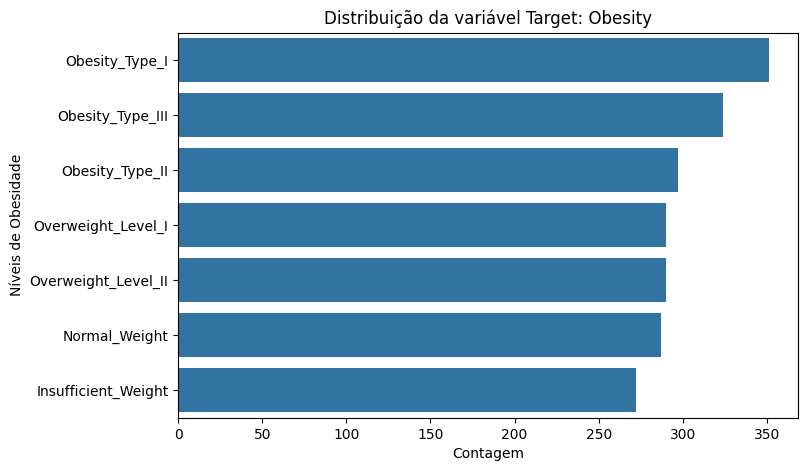

In [ ]:
# Criação do Gráfico Target para avaliar de forma visual a distribuição dos dados
plt.figure(figsize=(8,5))
sns.countplot(data=df_eda_obesidade,
              y="Obesity",
              order=df_eda_obesidade["Obesity"].value_counts().index)

plt.title("Distribuição da variável Target: Obesity")
plt.xlabel("Contagem")
plt.ylabel("Níveis de Obesidade")
plt.show()


#### Distribuição das variáveis numéricas

In [ ]:
num_cols = df_eda_obesidade.select_dtypes(include='number').columns
num_cols

Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')

In [ ]:
# Entender se há valores discrepantes
df_eda_obesidade[num_cols].describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


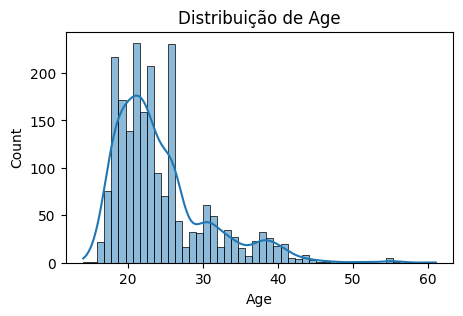

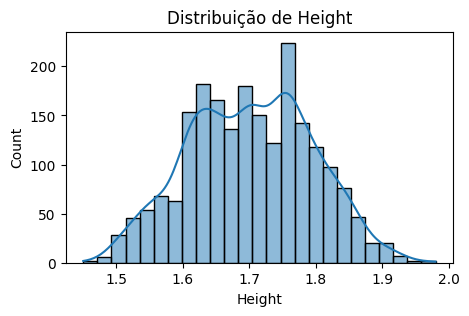

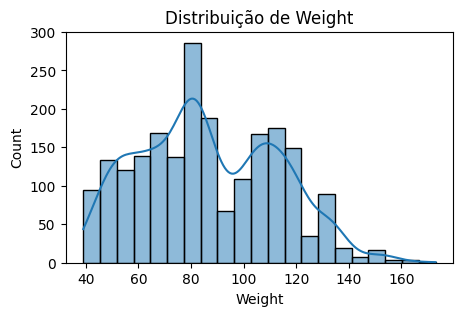

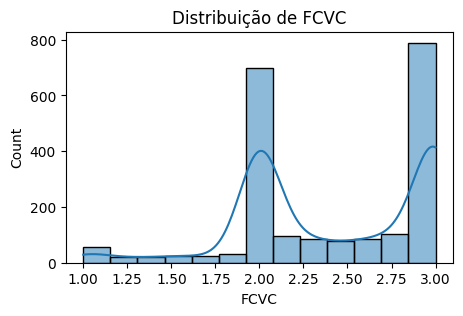

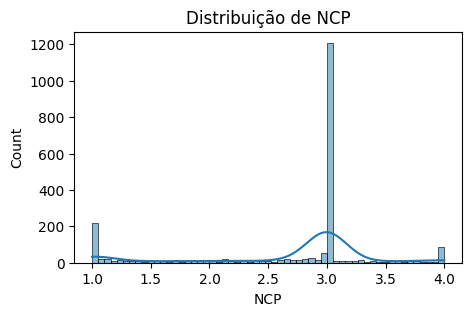

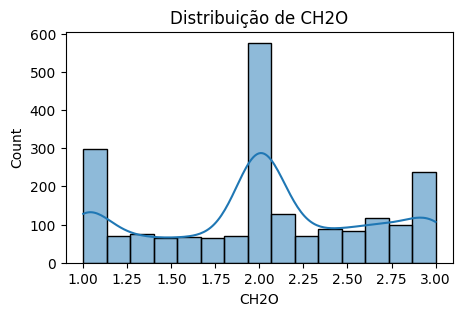

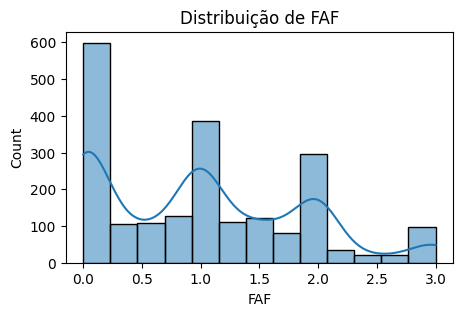

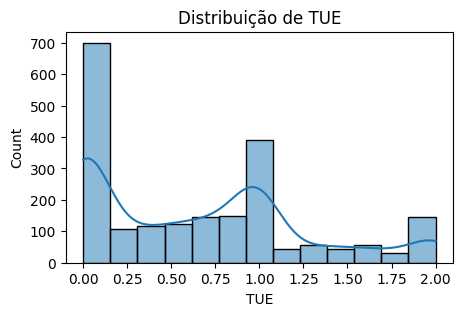

In [ ]:

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df_eda_obesidade[col], kde=True)
    plt.title(f"Distribuição de {col}")
    plt.show()


Através da análise descritiva, é possível observar que as variáveis físicas, como altura e peso, apresentam alta variabilidade. Já as variáveis relacionadas a hábitos e estilo de vida mostram distribuições mais concentradas, com menor presença de valores extremos.


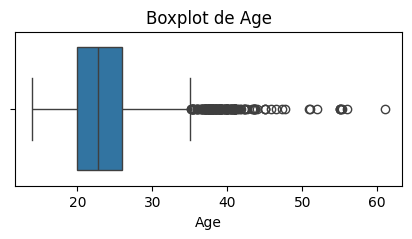

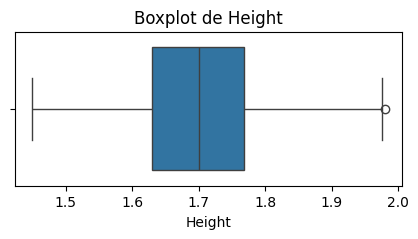

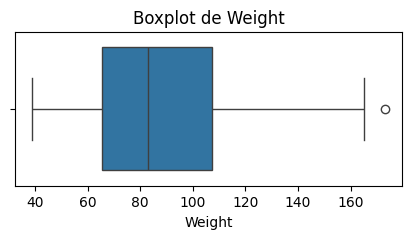

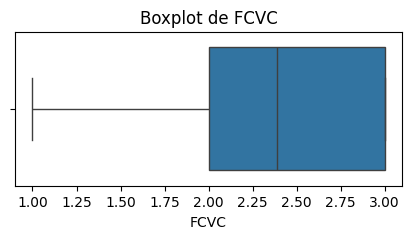

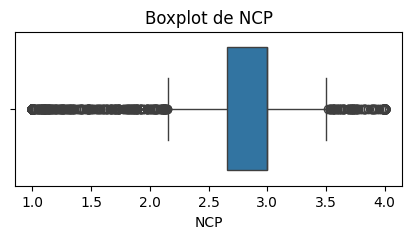

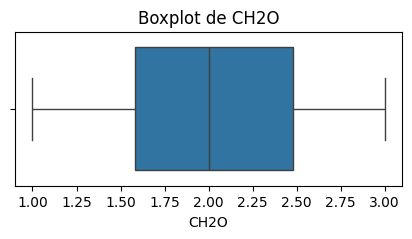

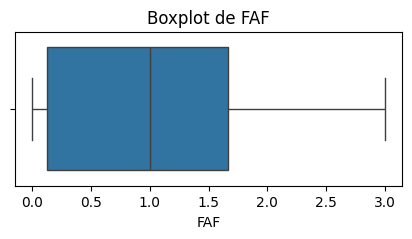

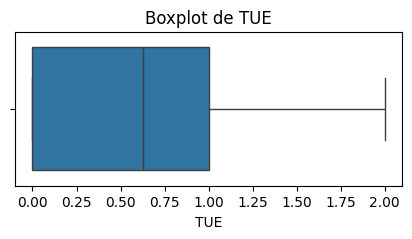

In [ ]:
# Analise com Boxplot para confirmar a ausencia de outliers
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df_eda_obesidade[col])
    plt.title(f"Boxplot de {col}")
    plt.show()


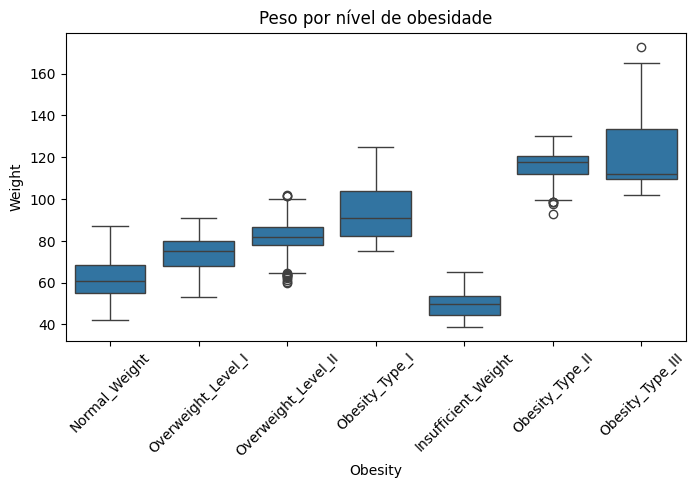

In [ ]:
#Nível de obsidade
plt.figure(figsize=(8,4))
sns.boxplot(x='Obesity', y='Weight', data=df_eda_obesidade)
plt.xticks(rotation=45)
plt.title("Peso por nível de obesidade")
plt.show()
